In [1]:
import numpy as np
import pickle
from tensorflow import keras
from tensorflow.keras.models import load_model, Model, clone_model
from tensorflow.keras.layers import Dropout

from sklearn.metrics import r2_score, mean_absolute_percentage_error, mean_squared_error
from matplotlib import pyplot as plt
from _utils import find_wlres, lorentz, fbg_reflection
import seaborn as sns
from scipy import stats, optimize
from interrogator_hardware import InterrogatorHardware
import pandas as pd
from _utils import transmission_spectra, my_gauss
from copy import copy
import warnings
import os

os.environ['TF_CPP_MIN_LOG_LEVEL']  = '2'
warnings.filterwarnings("ignore", category=UserWarning)

K = keras.backend

"""
plt.rcParams['mathtext.fontset'] = 'cm' # dejavuserif
plt.rcParams['legend.framealpha'] = 1
plt.rcParams['legend.fontsize'] = 'small'
plt.rcParams['legend.title_fontsize'] = 'medium'
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman',
                              'DejaVu Serif',
                              'Bitstream Vera Serif',
                              'Computer Modern Roman',
                              'New Century Schoolbook',
                              'Century Schoolbook L',
                              'Utopia',
                              'ITC Bookman',
                              'Bookman',
                              'Nimbus Roman No9 L',
                              'Times',
                              'Palatino',
                              'Charter',
                              'serif']
plt.rcParams['xtick.labelsize'] = 'small'
plt.rcParams['ytick.labelsize'] = 'small'
"""
plt.rcParams['legend.fontsize'] = 12

# Function definitions

## Functions to perform the Lorentzian approximation

In [2]:
def lorentz_estimation(fbgs, input_strength, full=False, restrict=False, bounds=None):
    """
    Estimates the resonant wavelength of an LPFG sensor based on filtered power, using a Lorentzian approximation.

    Parameters:
    fbgs (array-like): An array of wavelengths at which the FBG sensors collect power.
    input_strength (array-like): The corresponding array of input strength.
    full (bool, optional): Determines whether to return all fit parameters or just the resonant wavelength and its uncertainty. Defaults to False.
    restrict (bool, optional): Determines whether to restrict the fit to a certain wavelength range. Defaults to False.
    bounds (tuple, optional): Allows you to specify custom bounds for the fit parameters. If no bounds are provided, default bounds are used.

    Returns:
    tuple: If full is True, returns all fit parameters. If full is False, returns only the resonant wavelength and its uncertainty.
    """
    # Define constants
    # The wavelength range of the proposed interrogator
    WL_RANGE = (1515, 1585)
    # Median distance between FBG Bragg wavelengths
    DELTA_BRAGG = np.median(np.diff(fbgs))
    
    # Initial guess for the peak position is the wavelength with maximum power.
    wl_res_initial = fbgs[np.argmax(input_strength)]
    
    # Adjust initial guess and bounds if restrict is True
    if restrict:
        lower, upper = adjust_bounds(wl_res_initial, DELTA_BRAGG, WL_RANGE)
        bounds, p0 = set_bounds_and_initial_guess(bounds, input_strength, lower, upper, wl_res_initial)
    else:
        wl_res_initial = adjust_initial_guess(wl_res_initial, WL_RANGE)
        bounds, p0 = set_bounds_and_initial_guess(bounds, input_strength, *WL_RANGE, wl_res_initial)
    
    # Fit the data to the Lorentzian function
    try:
        par, pcov = optimize.curve_fit(lorentz, fbgs, input_strength, p0=p0, bounds=bounds)
    except Exception as e:
        print(f'Error: {e}\nInput: {(fbgs, input_strength)}\np0={p0}\nbounds={bounds}')
        return None

    # Return the fit parameters
    if full:
        return par
    else:
        perr = np.sqrt(np.diag(pcov))
        return par[1], 2*perr[1]


def adjust_bounds(wl_res_initial, delta_bragg, wl_range):
    """
    Adjusts the lower and upper bounds of the wavelength range.

    Parameters:
    wl_res_initial (float): Initial guess for the peak position.
    delta_bragg (float): Median difference between adjacent wavelengths.
    wl_range (tuple): Tuple containing the minimum and maximum wavelength.

    Returns:
    tuple: Adjusted lower and upper bounds of the wavelength range.
    """
    lower = max(wl_res_initial - delta_bragg, min(wl_range))
    upper = min(wl_res_initial + delta_bragg, max(wl_range))
    return lower, upper


def set_bounds_and_initial_guess(bounds, input_strength, lower, upper, wl_res_initial):
    """
    Sets the bounds and initial guess for the curve fitting.

    Parameters:
    bounds (tuple): Tuple containing the lower and upper bounds for the fit parameters.
    input_strength (array-like): The corresponding array of input strength.
    lower (float): Lower bound of the wavelength range.
    upper (float): Upper bound of the wavelength range.
    wl_res_initial (float): Initial guess for the peak position.

    Returns:
    tuple: Tuple containing the bounds and initial guess for the curve fitting.
    """
    if bounds is None:
        bounds = ((max(input_strength), lower,  5, 0), 
                  (1.00, upper, 50, max((min(input_strength)/2, 1e-3))))
        p0 = (1-1e-7, wl_res_initial, 10, 1e-7)
    else:
        p0 = None
    return bounds, p0


def adjust_initial_guess(wl_res_initial, wl_range):
    """
    Adjusts the initial guess for the peak position.

    Parameters:
    wl_res_initial (float): Initial guess for the peak position.
    wl_range (tuple): Tuple containing the minimum and maximum wavelength.

    Returns:
    float: Adjusted initial guess for the peak position.
    """
    if wl_res_initial < min(wl_range): 
        wl_res_initial = min(wl_range)
    if wl_res_initial > max(wl_range):
        wl_res_initial = max(wl_range)
    return wl_res_initial

## Functions to ease estimation using the SA-FCNN

In [3]:
def predict_with_uncertainty(f, x, n_iter=100):
    """
    Predict the output of a model with uncertainty.

    Parameters:
    f (function): The model function.
    x (array-like): The input data to the model.
    n_iter (int, optional): The number of iterations for uncertainty estimation. Defaults to 100.

    Returns:
    tuple: The predicted output and its uncertainty.
    """
    # Set the learning phase to 1 (training mode)
    K.set_learning_phase(1)
    # Initialize an array to store the results of each iteration
    result = np.zeros((n_iter, x[0].shape[0], 1))
    # Run the model function for each iteration and store the results
    for i in range(n_iter):
        result[i] = f(x)
    # Calculate the mean prediction across all iterations
    prediction = result.mean(axis=0)
    # Calculate the uncertainty of the prediction using the t-distribution
    uncertainty = stats.t.ppf(0.975, n_iter - 1) * result.std(axis=0)/np.sqrt(n_iter)
    # Set the learning phase back to 0 (test mode)
    K.set_learning_phase(0)
    # Return the prediction and its uncertainty
    return prediction.flatten(), uncertainty.flatten()


def get_lpfg_inputs(wavelength, lpfg_trans, fbg_pos, fbg_array, optical_source):
    """
    This function prepares the inputs for the LPFG estimation.

    Parameters:
    wavelength (array-like): The wavelength array for simulating the optical setup, given in nm.
    lpfg_trans (array-like): The LPFG transmission transfer function.
    fbg_pos (array-like): The FBG array Bragg wavelengths.
    fbg_array (array-like): The designed FBG array position. This can be different from fbg_pos since the FBG array could change with temperature and strain.
    optical_source (array-like): Optical source used to illuminate the LPFG and FBG

    Returns:
    tuple: The normalized difference between the filtered power and its full spectrum, and the normalized FBG positions.
    """
    # Define constants
    # Calculate the mean designed FBG spacing
    DELTA_BRAGG = np.mean(np.diff(fbg_array))

    # Initialize the interrogator hardware with the FBG array and FWHM
    interrogator_hardware = InterrogatorHardware(fbg_array=fbg_pos*1e-9, fwhm=100e-12)

    # Get the filtered power of the LPFG transmission plus the interpolated measured spectra
    filtered_power = interrogator_hardware.get_filtered_power(wavelength*1e-9, 
                                                              lpfg_trans + np.interp(wavelength*1e-9, 
                                                                                     optical_source[:, 0], optical_source[:, 1]))
    # Get the full spectrum of the filtered power
    source_power = interrogator_hardware.get_filtered_power(optical_source[:, 0], optical_source[:, 1])

    # Calculate the difference between the filtered power and its full spectrum
    input_strength = (filtered_power - source_power)

    # Normalize the difference
    input_strength = input_strength/np.sum(input_strength)

    # To improve robustness to power fluctuation 
    input_strength = input_strength - min(input_strength)
    input_strength = input_strength/np.sum(input_strength)
    
    # Normalize the FBG positions
    fbgs_distance = (fbg_pos - fbg_array)/DELTA_BRAGG

    return input_strength, fbgs_distance


def process_lpfg_batch(wavelength, array_lpfg_trans, fbg_pos, fbg_array, optical_source):
    """
    This function prepares a batch of LPFG tranferfunctions.

    Parameters:
    wavelength (array-like): The wavelength array for simulating the optical setup, given in nm.
    array_lpfg_trans (array-like): The LPFG transmission transfer function array, one per LPFG.
    fbg_pos (array-like): The FBG array Bragg wavelengths.
    fbg_array (array-like): The designed FBG array position. This can be different from fbg_pos since the FBG array could change with temperature and strain.
    optical_source (array-like): Optical source used to illuminate the LPFG and FBG

    Returns:
    tuple: The normalized difference between the filtered power and its full spectrum, and the normalized FBG positions.
    """
    array_input_strength = []
    array_fbgs_distance = []
    for lpfg_trans in array_lpfg_trans:
        input_strength, fbgs_distance = get_lpfg_inputs(wavelength, lpfg_trans, fbg_pos, fbg_array, optical_source)
        array_input_strength.append(input_strength)
        array_fbgs_distance.append(fbgs_distance)
    return np.array(array_input_strength), np.array(array_fbgs_distance)


def get_lpfg_target(wavelength, lpfg_trans):
    """
    This function gets the LPFG resonant wavelength.

    Parameters:
    wavelength (array-like): The wavelength array for the LPFG transmission transfer function, in nm.
    lpfg_trans (array-like): The LPFG transmission transfer function.

    Returns:
    tuple: The normalized difference between the filtered power and its full spectrum, and the normalized FBG positions.
    """
    # The wavelength range of the proposed interrogator
    WL_RANGE = (1515, 1585)
    wl_res = find_wlres(wavelength*1e-9, lpfg_trans)
    if wl_res > max(WL_RANGE) or wl_res < min(WL_RANGE):
        wl_res = np.nan
    return wl_res


def get_layer_outputs(model, inputs, layer_names):
    """
    This function retrieves the output of specific layers in a Keras model.

    Parameters:
    model (tensorflow.python.keras.engine.functional.Functional): The Keras functional model.
    inputs (numpy.ndarray): The input data as a numpy array.
    layer_names (list): A list of names of the layers whose outputs are to be retrieved.

    Returns:
    model_output (numpy.ndarray): The output of the entire model.
    intermediate_outputs (list): A list of numpy arrays representing the output of each specified layer.
    """ 

    # Create a list of output tensors for the layers we're interested in
    # This is done by iterating over the layers in the model and checking if their name is in the list of layer names
    output_tensors = [layer.output for layer in model.layers if layer.name in layer_names]

    # Create a new model that outputs these tensors given the original model's input
    # This is an 'intermediate' model that allows us to retrieve the outputs of specific layers
    intermediate_model = Model(inputs=model.input, outputs=output_tensors)

    # Use this model to predict on the inputs, giving the outputs of the desired layers
    # The output is a list of numpy arrays, one for each layer
    intermediate_outputs = intermediate_model.predict(inputs)

    # Also get the output of the original model
    # This is done by calling predict on the original model
    model_output = model.predict(inputs)

    return model_output, intermediate_outputs


# Data preparation

In [60]:
# Import relevant data
optical_source = np.load('./data/source.npy')

with open('./data/measured_spectra.dataset', 'rb') as file:
    measured_spectra = pickle.load(file)

with open('./data/measured.dataset', 'rb') as file:
    measured = pickle.load(file)

with open('./data/synth_extended.dataset', 'rb') as file:
    synth = pickle.load(file)

# Get the measured spectra resonant wavelength
wl_res = []
wl = measured_spectra['wl']
for tf in measured_spectra['transfer_fcn']:
    wl_res.append(
        get_lpfg_target(wl, tf)        
    )
measured_spectra['wl_res'] = np.array(wl_res)

In [68]:
# FBG designed Bragg wavelength and its spacing
base_position = np.linspace(1510, 1590, 13)
d_bragg = np.mean(np.diff(base_position))

X = synth['input_strength']
fbg_pos = synth['wl_bragg']
fbg_deviation = (fbg_pos - base_position)/d_bragg 
y = synth['target']*1e9
# To improve power fluctuation robustness
X = X - X.min(axis=1).reshape(-1, 1).repeat(13, axis=1)
X = X / X.sum(axis=1).reshape(-1, 1).repeat(13, axis=1)

keep = (y>1515) & (y<1585)
X, fbg_deviation, fbg_pos, y = X[keep], fbg_deviation[keep], fbg_pos[keep], y[keep]

pred, uncertainty = predict_with_uncertainty(f_model, [X, fbg_deviation], n_iter=10)

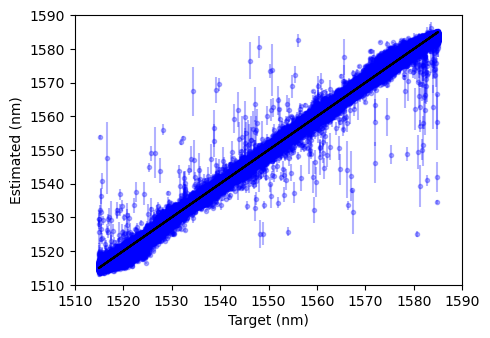

In [72]:
# Compare  the proposed model and the baseline
plt.figure(figsize=(5,3.5))
plt.errorbar(y, pred, yerr=uncertainty, fmt='.b', alpha=0.3, zorder=-1)
plt.plot(y, y, 'k', zorder=10)
plt.xlabel('Target (nm)')
plt.ylabel('Estimated (nm)')
plt.xlim(1510, 1590)
plt.ylim(1510, 1590)
plt.show()

In [74]:
mean_squared_error(y, pred)**0.5, 100*mean_absolute_percentage_error(y, pred), r2_score(y, pred)

(0.7677057338367606, 0.03158665963940901, 0.9985565956799176)

(-5.0, 5.0)

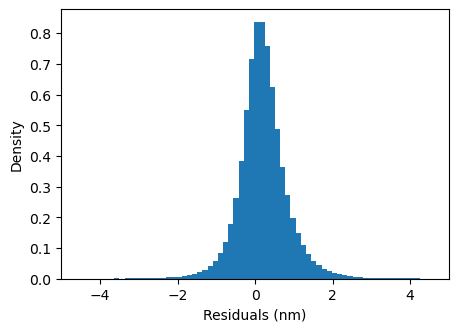

In [84]:
plt.figure(figsize=(5,3.5))

out = plt.hist(y - pred, bins=int(len(y)**0.5), density=True)
plt.xlabel('Residuals (nm)')
plt.ylabel('Density')
plt.xlim(-5, 5)

In [76]:
mask = abs(y - pred) > 2
sum(mask)/len(y)

0.015959903453427522

In [5]:
# FBG designed Bragg wavelength and its spacing
base_position = np.linspace(1510, 1590, 13)
d_bragg = np.mean(np.diff(base_position))

X = measured['input_strength']
fbg_pos = measured['wl_bragg']
fbg_deviation = (fbg_pos - base_position)/d_bragg 
y = measured['target']
# To improve power fluctuation robustness
X = X - X.min(axis=1).reshape(-1, 1).repeat(13, axis=1)
X = X / X.sum(axis=1).reshape(-1, 1).repeat(13, axis=1)

keep = (y>1515) & (y<1585)
X, fbg_deviation, fbg_pos, y = X[keep], fbg_deviation[keep], fbg_pos[keep], y[keep]

# Model evalution

In [30]:
# Load the model and the trained weights
model = load_model('./models/self_attention_2.keras', compile=False)
model.load_weights('./models/self_attention_weights_2.h5')

In [31]:
# Make predctions with dropout uncertainty evaluation
f_model = K.function(model.input,
                     model.output)

pred, uncertainty = predict_with_uncertainty(f_model, [X, fbg_deviation], n_iter=10)

In [32]:
# Get the lorentzian approximation for each spectrum and fbg positioning
lorentz_pred = []
lorentz_uncertainty = []
for x, f in zip(X, fbg_pos):
    m, u = lorentz_estimation(f, x)
    lorentz_pred.append(m)
    lorentz_uncertainty.append(u)
lorentz_pred = np.array(lorentz_pred)
lorentz_uncertainty = np.array(lorentz_uncertainty)

## Comparison

We found that the proposed model performs better than the baeline model (Loretzian fitting). 

The performace improvement is more prominent for some spectra, we searched for them and tried to explain this extensive difference.

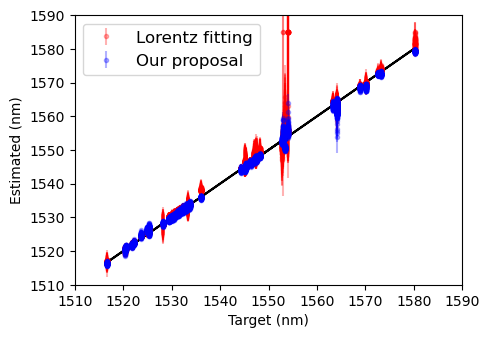

In [33]:
# Compare  the proposed model and the baseline
plt.figure(figsize=(5,3.5))
plt.errorbar(y, lorentz_pred, yerr=lorentz_uncertainty, fmt='.r', alpha=0.3, label='Lorentz fitting')
plt.errorbar(y, pred, yerr=uncertainty, fmt='.b', alpha=0.3, label='Our proposal')
plt.plot(y, y, 'k')
plt.legend(loc='upper left')
plt.xlabel('Target (nm)')
plt.ylabel('Estimated (nm)')
plt.xlim(1510, 1590)
plt.ylim(1510, 1590)
plt.show()

In [34]:
# Calculate the errors
e = y - pred
lore_e = y - lorentz_pred 
# Find the spectra where the Loretzian error is big
mask = abs(lore_e) > 5
wl_p = np.sort(np.unique(y[mask]))

In [35]:
wl_p

array([1552.782959, 1552.901123, 1553.491943, 1554.083374])

In [36]:
mask = abs(measured_spectra['wl_res'] - 1553.491943) < 1
measured_spectra['wl_res'][mask]

array([1552.782959, 1552.901123, 1554.083374, 1552.901123, 1553.373779])

[1552.782959]
[1552.901123 1552.901123]
[1553.373779]
[1554.083374]


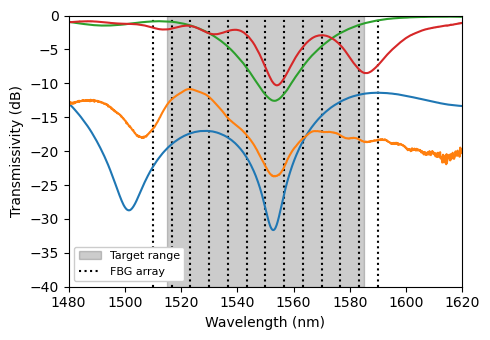

In [37]:
# Shows the problematic spectra
fig_spec = plt.figure(figsize=(5,3.5))
ax_spec = fig_spec.gca()

ax_spec.fill_between([1515, 1585], -40, y2=0, 
                 color='k', alpha=0.2,
                 label='Target range')
ax_spec.vlines(base_position, -40, 0, colors='k', linestyles=':', label='FBG array')
for problem in wl_p:
    mask = measured_spectra['wl_res'] == problem
    i = 0
    while sum(mask) == 0:
        loc = np.argsort(abs(measured_spectra['wl_res'] - problem))[i]
        if np.any(np.isnan(measured_spectra['wl_res'][mask])):
            i += 1
        else:
            mask[loc] = True
    print(measured_spectra['wl_res'][mask])
        
    ax_spec.plot(measured_spectra['wl'], measured_spectra['transfer_fcn'][mask][0], label=None)

    
ax_spec.set_xlim(1480, 1620)
ax_spec.set_ylim(-40, 0)
ax_spec.set_xlabel('Wavelength (nm)')
ax_spec.set_ylabel('Transmissivity (dB)')
ax_spec.legend(loc='lower left', framealpha=1, fontsize=8)


fig_spec.tight_layout()
plt.show()

We found that for spectra with distortions and some ripples, the Loretzian fit model had lower performance, specially when the sensor presents a second resonant wavelength outside the target interrogator range.

We believe that the incorporation of the attention mechanism could have improved this problem. This assumption was made because the attention mechanism might suppress the features related to the second resonant wavelength and other distortions, not related to the desired resonant wavlength.

## Performance metrics

Below one can find the performance metrics for both approaches, the proposed self-attention neural net and the baseline Loretzian fit.

We also restricted the dataset regarding the spectra which the Loretzian fit was to poor.

In [38]:
mask = abs(lore_e) < 5
metrics =  {  ('full dataset', 'rmse'): [mean_squared_error(y, pred)**0.5, 
                                         mean_squared_error(y, lorentz_pred)**0.5],
              ('full dataset', 'mape'): [100*mean_absolute_percentage_error(y, pred), 
                                         100*mean_absolute_percentage_error(y, lorentz_pred)],
              ('full dataset', 'r2'): [r2_score(y, pred), 
                                       r2_score(y, lorentz_pred)],
              ('no outliers', 'rmse'): [mean_squared_error(y[mask], pred[mask])**0.5, 
                                        mean_squared_error(y[mask], lorentz_pred[mask])**0.5],
              ('no outliers', 'mape'): [100*mean_absolute_percentage_error(y[mask], pred[mask]), 
                                        100*mean_absolute_percentage_error(y[mask], lorentz_pred[mask])],
              ('no outliers', 'r2'): [r2_score(y[mask], pred[mask]), 
                                      r2_score(y[mask], lorentz_pred[mask])]
                                   }
df_metrics = pd.DataFrame(metrics, index=['Proposed model', 'Loretzian fitted model'])
df_metrics


full dataset                     no outliers            \
                               rmse      mape        r2        rmse      mape   
Proposed model             0.999743  0.039705  0.995671    0.946666  0.038121   
Loretzian fitted model     1.944154  0.049977  0.983630    0.892400  0.041798   

                                  
                              r2  
Proposed model          0.996132  
Loretzian fitted model  0.996563

## Model weights

Below we show images containing the model's weights, i.e. the connection intensity at each layer. Note the clear division between input strength and fbg devation inputs at the Hidden and Attention layers.

In [39]:
def plot_weights(model):
    """
    Function to plot the weights of a Keras neural network as heatmaps.
    
    Parameters:
    model (keras.Model): Keras model to visualize the weights.

    Returns:
    None
    """
    for layer_num, layer in enumerate(model.layers):
        weights_biases = layer.get_weights()
        if weights_biases:  # this check will verify if the layer has weights and biases
            weights, biases = [a.T for a in weights_biases]
            fig = plt.figure(figsize=(3.4, 2.5))
            sns.heatmap(weights, cmap='viridis')
            plt.title('Weights of ' + layer.name)
            plt.xlabel('Layer input')
            plt.ylabel('Layer output')
            plt.show()

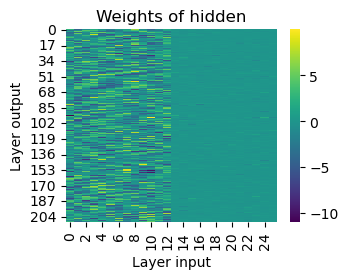

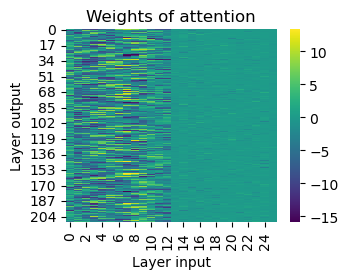

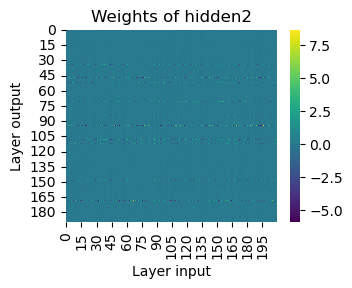

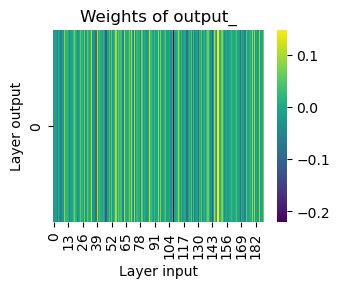

In [40]:
plot_weights(model)

## Layer outputs by resonant wavelength

Below we show what happends inside the model, we show each layer input as a funtion of the resonant wavelenght. 

As consequence, one can see what neurons are activated by each spectral region of LPFG spectra.

For those whanting to dive deeper into this, see Section *Exploring attention: LPFG position effect* for a simplified and more illustrative example, then return to this section.

In [41]:
# Get the intermediate layer outputs
intermediate_layers = ['hidden', 'attention', 'hidden2']
_, layers_output = get_layer_outputs(model, [X, fbg_deviation], intermediate_layers)
hidden_out, att_out, hidden2_out = layers_output
layers_output = {layer: output for layer, output in zip(intermediate_layers, layers_output)}

# Set the intervals for resonant wavelength grouping
dwl_res = 10
wlres_bins = np.arange(1515+dwl_res/2, 1585+dwl_res/2, dwl_res)

229/229 [==============================] - 0s 1ms/step


In [42]:
# Dict to save calculated data
intermediate_layers_stats = {layer: {'mean': [], 'std': []} for layer in intermediate_layers}

for wlres_center in wlres_bins:
    # Intervals
    lower, upper = wlres_center-dwl_res/2, wlres_center+dwl_res/2
    mask = (y > lower) & (y <= upper)
    # Mean behaviour of outputs
    for layer in intermediate_layers:
        intermediate_layers_stats[layer]['mean'].append(
            np.mean(layers_output[layer][mask], axis=0)
        )
    # Std of the mean of outputs
    for layer in intermediate_layers:
        intermediate_layers_stats[layer]['std'].append(
            np.std(layers_output[layer][mask], ddof=1, axis=0)/len(mask)**0.5
        )

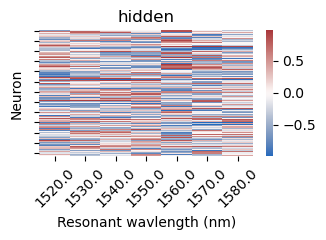

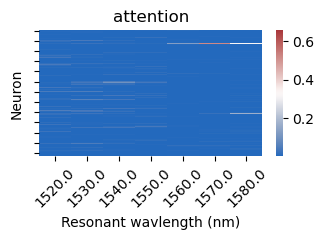

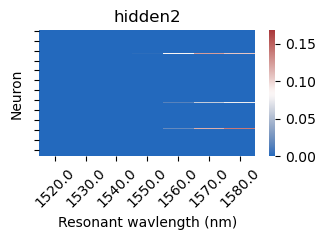

In [43]:
for layer in intermediate_layers:
    fig, ax = plt.subplots(figsize=(3.4, 2.5))
    sns.heatmap(np.array(intermediate_layers_stats[layer]['mean']).T, cmap='vlag', ax=ax)
    ax.set_xticklabels(wlres_bins, rotation=45)
    ax.set_yticklabels([])
    plt.title(layer)
    plt.xlabel('Resonant wavlength (nm)')
    plt.ylabel('Neuron')
    plt.tight_layout()
    plt.show()

## Exploring attention

Below we explore the attention mechanism, showing how the system behaves given two different LPFGs

In [53]:
# Function to compare the inputs, hidden layers and attention layer
def compare2inputs(model, x, fbg, input_names=None):
    """
    This function compares the outputs of two inputs on a given model.
    It visualizes the outputs of the 'hidden', 'attention', and 'hidden2' layers of the model.

    Parameters:
    model: The model to be used for comparison.
    x: The first input to the model.
    fbg: The second input to the model.
    input_names: The names of the inputs. Defaults to ['A', 'B'].

    Raises:
    ValueError: If more than two inputs are entered.
    """

    # Check if only two inputs are entered
    if x.shape[0] != 2 or fbg.shape[0] != 2:
        raise ValueError('Only two inputs should be entered!')

    # Set default input names if not provided
    if input_names is None:
        input_names = ['A', 'B']

    # Get the output and the intermediate layers' outputs of the model for the two inputs
    out, intermediate_layers = get_layer_outputs(model, [x, fbg], ['hidden', 'attention', 'hidden2'])

    # Extract the outputs of the 'hidden', 'attention', and 'hidden2' layers
    hidden, att, hiden2 = intermediate_layers

    # Create a figure for the subplots
    fig = plt.figure(figsize=(2*5, 3.5))


    # Define the subplots
    ax0 = fig.add_subplot(2, 3, 1)  # First row, first column
    ax1 = fig.add_subplot(2, 3, 4)  # Second row, first column
    ax2 = fig.add_subplot(1, 3, 2)  # Both rows, second column
    ax3 = fig.add_subplot(1, 3, 3)  # Both rows, third column

    # List of axes for easy access
    ax = [ax0, ax1, ax2, ax3]

    # Plot heatmaps of the inputs and the 'hidden' layer outputs
    sns.heatmap(x, cmap='rocket_r', vmin=0, vmax=1, square=False, cbar=True, ax=ax[0], cbar_kws={'label': 'Input strength'})
    sns.heatmap(fbg, cmap='vlag', vmin=-1, vmax=1, square=False, cbar=True, ax=ax[1], cbar_kws={'label': 'FBG deviation'})
    sns.heatmap(hidden, cmap='vlag', vmin=-1, vmax=1, square=False, cbar=False, ax=ax[2], cbar_kws={'label': 'Neuron out.'})

    # Plot the 'attention' layer output
    ax[2].plot(0.5-att[0, :], '-k', lw=2, alpha=0.7)
    ax[2].plot(1.5-att[1, :], '-k', lw=2, alpha=0.7)

    # Plot heatmap of the 'hidden2' layer output
    sns.heatmap(hiden2, cmap='vlag', vmin=-1, vmax=1, square=False, cbar=False, ax=ax[3], cbar_kws={'label': 'Neuron out.'})

    # Remove x-axis labels for the first subplot
    ax[0].set_xticklabels([])

    # Set y-axis labels for all subplots
    for axi in ax:
        axi.set_yticklabels(input_names)

    # Set x-axis label for the last 3 subplots
    for axi in ax[1::]:
        axi.set_xlabel('Neuron')

    # Adjust colorbar label size for the first two subplots
    cbar = ax[0].collections[0].colorbar
    cbar.ax.yaxis.label.set_size(8)
    cbar = ax[1].collections[0].colorbar
    cbar.ax.yaxis.label.set_size(8)

    # Adjust layout and display the plot
    plt.tight_layout()
    plt.show()


### LPFG position effect

Here we show how the outputs change given a LPFG shift. It is the same analysis as presented in the *Layer outputs by resonant wavelength* section, but with a synthetic spectrum, static FBG array and input demonstration, for better visualization.

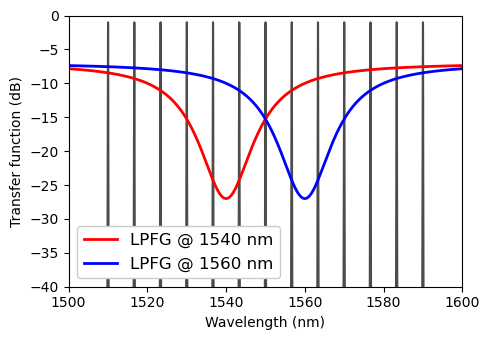

In [54]:
# Create an LPFG transmission function at 1540
dip_depth, resonant_wl, dip_width, insertion_loss =  20, 1540, 40, 7
transfer_1540 = transmission_spectra(wl, dip_depth, resonant_wl, dip_width, insertion_loss)
# Create an LPFG transmission function at 1560
dip_depth, resonant_wl, dip_width, insertion_loss =  20, 1560, 40, 7
transfer_1560 = transmission_spectra(wl, dip_depth, resonant_wl, dip_width, insertion_loss)
plt.figure(figsize=(5,3.5))
for fbg in base_position:
    wl_sim = np.linspace(fbg-1, fbg+1, 1000)
    fbg_r = fbg_reflection(fbg*1e-9, 100e-12, wl_sim*1e-9) - 1
    plt.plot(wl_sim, fbg_r, 'k', alpha=0.7)
plt.plot(wl, transfer_1540, 'r', lw=2, label='LPFG @ 1540 nm')
plt.plot(wl, transfer_1560, 'b', lw=2, label='LPFG @ 1560 nm')
plt.xlim(1500, 1600)
plt.ylim(-40, 0)
plt.xlabel('Wavelength (nm)')
plt.ylabel('Transfer function (dB)')
plt.legend(loc='lower left', framealpha=1)
plt.tight_layout()
plt.show()

1540: 1540.04 +- 0.17
1560: 1559.76 +- 0.18
1/1 [==============================] - 0s 17ms/step


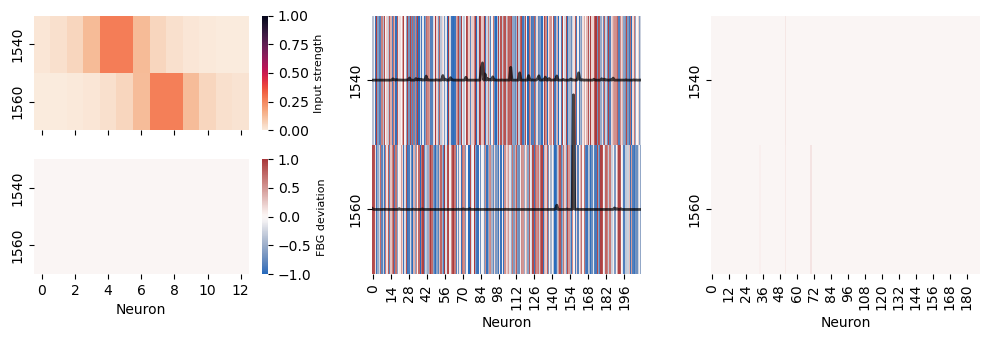

In [55]:
x_a, fbg = get_lpfg_inputs(wl, transfer_1540, base_position, base_position, optical_source)
y_a, u_a = predict_with_uncertainty(f_model, [x_a.reshape(1,-1), fbg.reshape(1,-1)], n_iter=10)

x_b, fbg = get_lpfg_inputs(wl, transfer_1560, base_position, base_position, optical_source)
y_b, u_b = predict_with_uncertainty(f_model, [x_b.reshape(1,-1), fbg.reshape(1,-1)], n_iter=10)

print(f'1540: {y_a[0]:.2f} +- {u_a[0]:.2f}')
print(f'1560: {y_b[0]:.2f} +- {u_b[0]:.2f}')

x = np.array([x_a, x_b])
fbg = np.array([fbg, fbg])

compare2inputs(model, x, fbg, input_names=['1540', '1560'])

### Ideal vs distorted LPFG

Below we create a LPFG transmission function with a single distinct resonant dip and another one with some distortions and a second dip outside the interrogator range.

This might be the most influential part of attention!

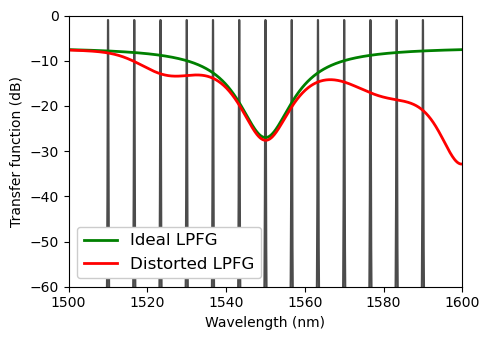

In [56]:
# Create an ideal synthetic LPFG transmission function
dip_depth, resonant_wl, dip_width, insertion_loss =  20, 1550, 40, 7
transfer = transmission_spectra(wl, dip_depth, resonant_wl, dip_width, insertion_loss)
plt.figure(figsize=(5,3.5))
for fbg in base_position:
    wl_sim = np.linspace(fbg-1, fbg+1, 1000)
    fbg_r = fbg_reflection(fbg*1e-9, 100e-12, wl_sim*1e-9) - 1
    plt.plot(wl_sim, fbg_r, 'k', alpha=0.7)
plt.plot(wl, transfer, 'g', lw=2, label='Ideal LPFG')
plt.xlim(1500, 1600)
plt.ylim(-60, 0)

# Create an LPFG with some distortions
transfer_2 = copy(transfer) + transmission_spectra(wl, dip_depth+5, 1600, dip_width+5, insertion_loss)
transfer_2 += my_gauss(wl, 4, 1525, 10, 0)
transfer_2 += my_gauss(wl, 6, 1580, 20, 0)
il_dif = max(transfer) - max(transfer_2)
transfer_2 += il_dif
plt.plot(wl, transfer_2, 'r', lw=2, label='Distorted LPFG')
plt.xlabel('Wavelength (nm)')
plt.ylabel('Transfer function (dB)')
plt.legend(loc='lower left', framealpha=1)
plt.tight_layout()
plt.show()

Ideal: 1549.91 +- 0.17
Distorted: 1550.09 +- 0.36
1/1 [==============================] - 0s 16ms/step


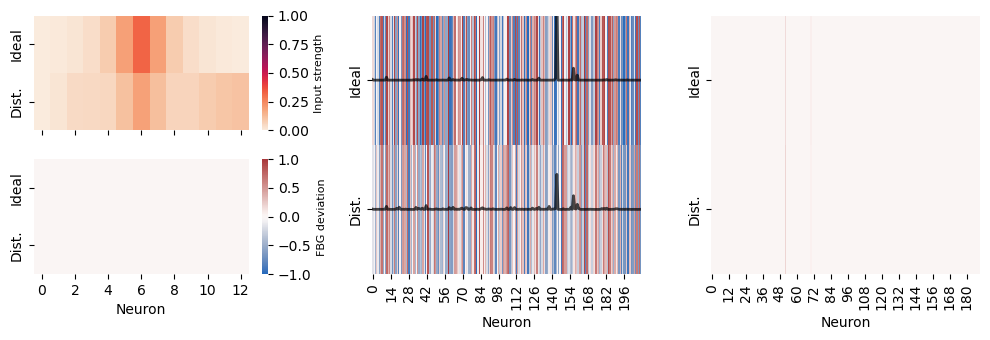

In [57]:
x_ideal, fbg = get_lpfg_inputs(wl, transfer, base_position, base_position, optical_source)
y_ideal, u_ideal = predict_with_uncertainty(f_model, [x_ideal.reshape(1,-1), fbg.reshape(1,-1)], n_iter=10)

x_dist, fbg = get_lpfg_inputs(wl, transfer_2, base_position, base_position, optical_source)
y_dist, u_dist = predict_with_uncertainty(f_model, [x_dist.reshape(1,-1), fbg.reshape(1,-1)], n_iter=10)

print(f'Ideal: {y_ideal[0]:.2f} +- {u_ideal[0]:.2f}')
print(f'Distorted: {y_dist[0]:.2f} +- {u_dist[0]:.2f}')

x = np.array([x_ideal, x_dist])
fbg = np.array([fbg, fbg])

compare2inputs(model, x, fbg, input_names=['Ideal', 'Dist.'])

One can see that the attention layer keeps the same component in the Ideal and Distorted LPFG spectra, as the conrresponding hidden feature might be very important for LPFG demodulation. However, other peaks arises and/or increase value.

At the second hidden layer one can see the virtually the same output. At the model's output, both cases are close to the target value of 1550 nm.

### FBG array movement

Below we explore the effect of FGB deviation. An example with the FBG array at the designed position and another at a different position.

One can see a great difference at the input layer, but a verry good estimation for both. The attention and second hidden effects are simular to the shown before.

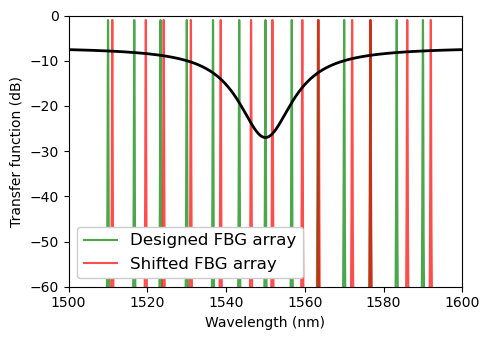

In [58]:
# Create an ideal synthetic LPFG transmission function
dip_depth, resonant_wl, dip_width, insertion_loss =  20, 1550, 40, 7
transfer = transmission_spectra(wl, dip_depth, resonant_wl, dip_width, insertion_loss)
plt.figure(figsize=(5,3.5))

shifted_fbg = np.array([1511.08, 1519.59, 1524.13, 1531.04, 1538.62, 1546.34, 1551.76, 1559.36, 1563.5 , 1572.02, 1576.67, 1586.02, 1592.  ])
fbg_r_design = []
fbg_r_shift = []
wl_fbg = []
for fbg_design, fbg_shift in zip(base_position, shifted_fbg):
    wl_sim = np.linspace(fbg_design-4, fbg_design+5, 5000)
    fbg_r_design.append(fbg_reflection(fbg_design*1e-9, 100e-12, wl_sim*1e-9) - 1)
    fbg_r_shift.append(fbg_reflection(fbg_shift*1e-9, 100e-12, wl_sim*1e-9) - 1)
    wl_fbg.append(wl_sim)
wl_fbg = np.array(wl_fbg).flatten()
fbg_r_design = np.array(fbg_r_design).flatten()
fbg_r_shift = np.array(fbg_r_shift).flatten()

plt.plot(wl_fbg, fbg_r_design, 'g', alpha=0.7, label='Designed FBG array')
plt.plot(wl_fbg, fbg_r_shift, 'r', alpha=0.7, label='Shifted FBG array')

plt.plot(wl, transfer, 'k', lw=2, label=None)
plt.xlim(1500, 1600)
plt.ylim(-60, 0)
plt.xlabel('Wavelength (nm)')
plt.ylabel('Transfer function (dB)')
plt.legend(loc='lower left', framealpha=1)
plt.tight_layout()
plt.show()

Ideal: 1549.83 +- 0.26
Shifted: 1550.63 +- 0.31
1/1 [==============================] - 0s 16ms/step


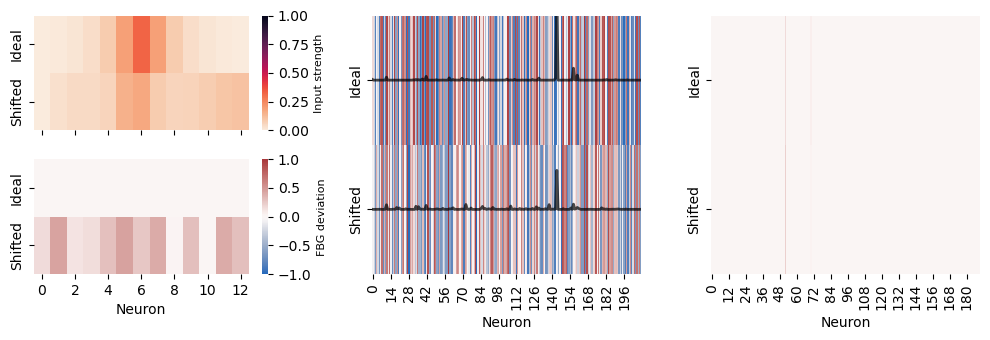

In [59]:
x_ideal, fbg = get_lpfg_inputs(wl, transfer, base_position, base_position, optical_source)
y_ideal, u_ideal = predict_with_uncertainty(f_model, [x_ideal.reshape(1,-1), fbg.reshape(1,-1)], n_iter=10)

x_shifted, fbg_shifted = get_lpfg_inputs(wl, transfer_2, shifted_fbg, base_position, optical_source)
y_shifted, u_shifted = predict_with_uncertainty(f_model, [x_shifted.reshape(1,-1), fbg_shifted.reshape(1,-1)], n_iter=10)

print(f'Ideal: {y_ideal[0]:.2f} +- {u_ideal[0]:.2f}')
print(f'Shifted: {y_shifted[0]:.2f} +- {u_shifted[0]:.2f}')

x = np.array([x_ideal, x_shifted])
fbg = np.array([fbg, fbg_shifted])

compare2inputs(model, x, fbg, input_names=['Ideal', 'Shifted'])

Please note that the model uncertainty increased in all cases when the input was far from the ideal scenario, both the distorted LPFG and the shifted FBG. Therefore, we could see thaty the dropout uncertainty estimation is indeed penalizing difficuilt cases.

## Model sensitivity to FBG shifting

Below we compare measurements made by the static FBG array, at its designed position, against a shifted FBG array. 

We shifted each FBG element, individually and evaluated the Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), residues' bias and residues' standard deviation.

Both were compared, to see if incorporating FBG shift compromizes the LPFG estimation. We also calculated the correlation between the FBG shift and each metric at each FBG element, to see if a particular element is more affected by shifting.

In [ ]:
# FBG array at the designed position, as baseline
input_strength, fbg_deviation = process_lpfg_batch(wl, measured_spectra['transfer_fcn'], 
                                                           base_position, base_position, optical_source)
# Make prediction
y_designed, _ = predict_with_uncertainty(f_model, [input_strength, fbg_deviation], n_iter=10)
res = y_designed-measured_spectra['wl_res']
res = res[~np.isnan(res)]
metrics_designed = {'mae': np.mean(np.abs(res)),
                    'rmse': np.mean((res)**2)**0.5,
                    'mu': np.mean(res),
                    'std': np.std(res, ddof=1)
                    }

In [ ]:
# Maximum FBG shift supported by the model (based on training data and FBG superposition avoidance)
bragg_shift = np.linspace(-0.48, 0.48, 15) * d_bragg
# Structure tyo save the metrics
metrics = {'mae': np.zeros((len(base_position), len(bragg_shift))),
           'rmse': np.zeros((len(base_position), len(bragg_shift))),
           'mu': np.zeros((len(base_position), len(bragg_shift))),
           'std': np.zeros((len(base_position), len(bragg_shift)))}

# Simulation on shifting each FBG of the array, individually
for i, bragg_wavelength in enumerate(base_position):
    for j, each_shift in enumerate(bragg_shift):
        # Shift the FBG array
        fbg_array = copy(base_position)
        fbg_array[fbg_array==bragg_wavelength] += each_shift
        # Simulate the input
        input_strength, fbg_deviation = process_lpfg_batch(wl, measured_spectra['transfer_fcn'], 
                                                           fbg_array, base_position, optical_source)
        # Make prediction
        y_shifted, _ = predict_with_uncertainty(f_model, [input_strength, fbg_deviation], n_iter=10)
        # Evaluate prediction
        res = y_shifted-measured_spectra['wl_res']
        res = res[~np.isnan(res)]
        metrics['mae'][i, j] = np.mean(np.abs(res))
        metrics['rmse'][i, j] = np.mean(res**2)**0.5
        metrics['mu'][i, j] = np.mean(res)
        metrics['std'][i, j] = np.std(res, ddof=1)

In [ ]:
def fbg_shift_effect(metrics, metric, metric_name):
    """
    Function to plot the effect of Bragg wavelength shift on a given metric.
    
    Parameters:
    metrics (dict): Dictionary containing the metrics data.
    metric (str): The specific metric to be analyzed.
    metric_name (str): The name of the metric to be used in plot labels.

    Returns:
    min_metric (float): The minimum value of the metric.
    mean_metric (float): The mean value of the metric.
    max_metric (float): The maximum value of the metric.
    """
    # Create a DataFrame from the metrics data
    df = pd.DataFrame(metrics[metric], 
                      index=np.round(base_position, decimals=1), 
                      columns=np.round(bragg_shift, decimals=1)).T

    corr = []  # List to store correlation coefficients

    # Calculate the correlation coefficient between the metric and the Bragg shift for each column
    for column in df.columns:
        r, p_value = stats.pearsonr(df.index.values, df[column].values)
        corr.append(r)

    # Plot the metric values as a heatmap
    plt.figure(figsize=(3.4, 2.5))
    sns.heatmap(df, cmap='rocket_r', cbar_kws={'label': f'{metric_name} (nm)'})
    plt.xlabel('FBG element @ $\lambda_{Bragg_0}$ (nm)')
    plt.ylabel('$\lambda_{Bragg}$ shift (nm)')
    plt.tight_layout()
    plt.show()

    # Plot the correlation coefficients
    plt.figure(figsize=(3.4, 2.5))
    plt.plot(base_position, corr)
    plt.xlabel('FBG element @ $\lambda_{Bragg_0}$ (nm)')
    plt.ylabel(f'Shift $\\times$ {metric_name} \ncorrelation')
    plt.tight_layout()
    plt.show()

    # Returns the metrics' stats
    return np.min(df), np.mean(df), np.max(df)


In [ ]:
metric, metric_name = 'mae', 'MAE'
metric_stats = fbg_shift_effect(metrics, metric, metric_name)

expected_metric = metrics_designed[metric]
print(f'Expected metric: {expected_metric:.2f} nm\nWhen shifted: \n\tMean:\t\t{metric_stats[1]:.2f} nm\n\tExtremes:\t{metric_stats[0]:.2f} ~ {metric_stats[2]:.2f} nm')

In [ ]:
metric, metric_name = 'rmse', 'RMSE'
metric_stats = fbg_shift_effect(metrics, metric, metric_name)

expected_metric = metrics_designed[metric]
print(f'Expected metric: {expected_metric:.2f} nm\nWhen shifted: \n\tMean:\t\t{metric_stats[1]:.2f} nm\n\tExtremes:\t{metric_stats[0]:.2f} ~ {metric_stats[2]:.2f} nm')

In [ ]:
metric, metric_name = 'mu', 'Residues bias'
metric_stats = fbg_shift_effect(metrics, metric, metric_name)

expected_metric = metrics_designed[metric]
print(f'Expected metric: {expected_metric:.2f} nm\nWhen shifted: \n\tMean:\t\t{metric_stats[1]:.2f} nm\n\tExtremes:\t{metric_stats[0]:.2f} ~ {metric_stats[2]:.2f} nm')

In [ ]:
metric, metric_name = 'std', 'Residues $\sigma$'
metric_stats = fbg_shift_effect(metrics, metric, metric_name)

expected_metric = metrics_designed[metric]
print(f'Expected metric: {expected_metric:.2f} nm\nWhen shifted: \n\tMean:\t\t{metric_stats[1]:.2f} nm\n\tExtremes:\t{metric_stats[0]:.2f} ~ {metric_stats[2]:.2f} nm')

The results showed that all FBG elements were impacted by the Bragg shifting. Note that there wasn't a clear differtence in a particular element of the FBG array. 

As the metrics variation, the results showed the mean behaviour of the shifted arrays was in accordance to the static array, with some minor deviations. Hence, the FBG shifting does not affect significantly the LPFG demodulation procedure, moreover the added uncertainty is captured by the model, as shown in previous section.